In [2]:
!pip install adjustText

In [1]:
# %%
# Analyze the flow data to identify the peak flow and its timing during the flood event
from PIL.Image import logger
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import glob

import rasterio


PROJECT_ROOT = "/home/91/23016891/projects/carlisle"
BC_DATA_DIR = f"/data/westport/data/flood-mapping-with-ml-main-DATA/DATA/boundary_conditions"
GRAPH_OUTPUT_DIR = f"{PROJECT_ROOT}/out"
FLOOD_MAPS_DIR  = "/data/westport/data/flood_maps"
ML_DATA_DIR = f"/data/westport/data/flood-mapping-with-ml-main-DATA/DATA/"


def create_indices():
    event_index = {
        # 0: "July2021",
        1: "Base0",
        2: "Base1",
        3: "Base2",
        4: "Base3",
        5: "Base4",
        6: "Base5",
        7: "Base6",
        8: "Base7",
        9: "Base8", 
    }
    for i in range(1,98):
        event_index[9+i] = f"S{i:02d}"
        
    event_name_map = {
        # "July2021": "July 2021 Flood",
        "Base0": "Base0_Buller20yrARI_v2",
        "Base1": "Base1_Buller50yrARI_v2",
        "Base2": "Base2_Buller100yrARI",
        "Base3": "Base3_Buller50yrARI_RCP4pt5",
        "Base4": "Base4_Buller50yrARI_RCP6pt0",
        "Base5": "Base5_Buller50yrARI_RCP8pt5",
        "Base6": "Base6_Buller100yrARI_RCP4pt5",
        "Base7": "Base7_Buller100yrARI_RCP6pt0",
        "Base8": "Base8_Buller100yrARI_RCP8pt5"
    }
    
    for i in range(1,98):
        event_name_map[f"S{i:02d}"] = f"S{i:02d}"
    return event_index, event_name_map

event_index_map, event_name_map = create_indices()

def extract_timestep_from_filename(filename):
    try:
        # Timestep format is depth_at_2000-01-02_00-00-00.tif, so we need to extract the part after 'depth_at_' and before '.tif'
        timestep_str = filename.split("depth_at_")[1].split(".tif")[0]
        # Convert to datetime object
        timestep_dt = pd.to_datetime(timestep_str, format="%Y-%m-%d_%H-%M-%S")
        return timestep_dt
    except Exception as e:
        logger.error(f"Error extracting timestep from filename {filename}: {e}")
        return None
    
def preprocess_boundary_conditions():
        event_data_map = {} # Store flood map file paths for each event
        
        for event_id in event_index_map.keys():
            event_index = event_index_map[event_id]
            logger.info(f"Preprocessing boundary conditions for event ID: {event_id}, Event Name: {event_name_map[event_index]} Event Index: {event_index}")
            inflow_file = os.path.join(BC_DATA_DIR, f"{event_index}.csv")
            inflow_data = pd.read_csv(inflow_file)
            
            # Drop first column as it is just an index column
            # inflow_data = inflow_data.drop(inflow_data.columns[0], axis=1)
            
            event_name = event_name_map[event_index_map[event_id]]
            
            flood_map_files = glob.glob(f"{FLOOD_MAPS_DIR}/{event_name}_depth_snapshots/depth_at_*.tif")
            flood_map_files.sort()
            
            # Extract the timestamp from the flood map file names and store in a list
            flood_map_timestamps = [extract_timestep_from_filename(file) for file in flood_map_files]
            logger.info(f"Extracted {len(flood_map_timestamps)} flood map   timestamps for event ID: {event_id}")
            
            #Add a column to the inflow data for the corresponding flood map timestamp. If not found add a default value.
            inflow_data['Date_Time'] = pd.to_datetime(inflow_data['Date_Time'])
            inflow_data['Flood_Map_Available'] = inflow_data['Date_Time'].apply(lambda x: True if x in flood_map_timestamps else False)
            inflow_data['flood_map_file'] = inflow_data['Date_Time'].apply(lambda x: next((file for file in flood_map_files if extract_timestep_from_filename(file) == x), None))
            
            #drop rows where flood map file is not available
            inflow_data = inflow_data[inflow_data['Flood_Map_Available']]
            inflow_data.drop(columns=['Flood_Map_Available'], inplace=True)
            event_data_map[event_id] = inflow_data
            print(f"Event ID: {event_id}, Event Name: {event_name}, Number of timesteps with flood maps: {len(inflow_data)}")
        
    
        #save a separate csv file with the event data map for each event
        for event_id, inflow_data in event_data_map.items():
            inflow_data.to_csv(os.path.join(GRAPH_OUTPUT_DIR, "westport",  f"event_{event_id}.csv"), index=False)   
        return event_data_map
event_data_map = preprocess_boundary_conditions()

Event ID: 1, Event Name: Base0_Buller20yrARI_v2, Number of timesteps with flood maps: 50
Event ID: 2, Event Name: Base1_Buller50yrARI_v2, Number of timesteps with flood maps: 50
Event ID: 3, Event Name: Base2_Buller100yrARI, Number of timesteps with flood maps: 50
Event ID: 4, Event Name: Base3_Buller50yrARI_RCP4pt5, Number of timesteps with flood maps: 54
Event ID: 5, Event Name: Base4_Buller50yrARI_RCP6pt0, Number of timesteps with flood maps: 57
Event ID: 6, Event Name: Base5_Buller50yrARI_RCP8pt5, Number of timesteps with flood maps: 57
Event ID: 7, Event Name: Base6_Buller100yrARI_RCP4pt5, Number of timesteps with flood maps: 54
Event ID: 8, Event Name: Base7_Buller100yrARI_RCP6pt0, Number of timesteps with flood maps: 57
Event ID: 9, Event Name: Base8_Buller100yrARI_RCP8pt5, Number of timesteps with flood maps: 57
Event ID: 10, Event Name: S01, Number of timesteps with flood maps: 62
Event ID: 11, Event Name: S02, Number of timesteps with flood maps: 49
Event ID: 12, Event Name: 

In [4]:
event_data_map.keys()


dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106])

In [15]:
import torch


def analyze_events():
    
    event_peaks = {}
    #analyse peak flow and its timing for each event
    for event_id, inflow_data in event_data_map.items():
        peak_flow = inflow_data['River_flow'].max()
        row_of_peak_flow = inflow_data.loc[inflow_data['River_flow'] == peak_flow].iloc[0]
        peak_time = row_of_peak_flow['Date_Time']
        peak_timestep = (peak_time - inflow_data['Date_Time'].min()).total_seconds() / 3600  # Time from start of event in hours
        logger.info(f"Event ID: {event_id}, Event Name: {event_name_map[event_index_map[event_id]]}, Peak Flow: {peak_flow}, Peak Time: {peak_time}")   
        
        peak_sea_level = inflow_data['Sea_level'].max()
        row_of_peak_sea_level = inflow_data.loc[inflow_data['Sea_level'] == peak_sea_level].iloc[0]
        peak_sea_level_time = row_of_peak_sea_level['Date_Time']
        peak_sea_level_timestep = (peak_sea_level_time - inflow_data['Date_Time'].min()).total_seconds() / 3600  # Time from start of event in hours
        logger.info(f"Event ID: {event_id}, Event Name: {event_name_map[event_index_map[event_id]]}, Peak Sea Level: {peak_sea_level}, Peak Sea Level Time: {peak_sea_level_time}")
        
        event_duration_hours = (inflow_data['Date_Time'].max() - inflow_data['Date_Time'].min()).total_seconds() / 3600
        number_of_timesteps = len(inflow_data)
        logger.info(f"Event ID: {event_id}, Event Name: {event_name_map[event_index_map[event_id]]}, Event Duration: {event_duration_hours} hours")
        event_peaks[event_id] = {
            "number_of_timesteps": number_of_timesteps,
            "peak_flow": peak_flow,
            "peak_timestep": peak_timestep,
            "peak_sea_level": peak_sea_level,
            "peak_sea_level_timestep": peak_sea_level_timestep,
            "event_duration_hours": event_duration_hours
        }
        
        
    #find study domain size and resolution from the flood maps of the first event
    first_event_flood_maps = glob.glob(f"{FLOOD_MAPS_DIR}/{event_name_map[event_index_map[1]]}_depth_snapshots/depth_at_*.tif")
    if first_event_flood_maps:
        with rasterio.open(first_event_flood_maps[0]) as src:
            domain_width = src.width
            domain_height = src.height
            resolution = src.res[0]  # Assuming square pixels
            print(f"Study domain size: {domain_width} x {domain_height} pixels, Resolution: {resolution} meters/pixel")
    else:
        print("No flood maps found for the first event.")

    volume_peaks = {}
    for event_id, inflow_data in event_data_map.items():
        flood_map_files = inflow_data['flood_map_file'].dropna().tolist()
        valid_rows      = inflow_data[inflow_data['flood_map_file'].notna()].reset_index(drop=True)
        
        chunk_size  = 10
        all_volumes = []

        for i in range(0, len(flood_map_files), chunk_size):
            if i + chunk_size > len(flood_map_files):
                chunk_size = len(flood_map_files) - i
            chunk_files = flood_map_files[i:i + chunk_size]

            arrays = []
            for f in chunk_files:
                with rasterio.open(f) as src:
                    arrays.append(src.read(1))

            batch = torch.from_numpy(np.stack(arrays, axis=0)).float().cuda()
            batch = torch.nan_to_num(batch, nan=0.0).clamp(min=0.0)

            volumes = batch.sum(dim=(1, 2)) * (resolution ** 2)
            all_volumes.append(volumes.cpu())  # move back to CPU to free VRAM

            del batch  # explicitly free GPU memory after each chunk
            torch.cuda.empty_cache()

        # Concatenate all chunk results on CPU
        all_volumes     = torch.cat(all_volumes)
        peak_volume_idx = all_volumes.argmax().item()
        max_volume      = all_volumes[peak_volume_idx].item()
        max_volume_time = valid_rows.loc[peak_volume_idx, 'Date_Time']

        print(f"Event ID: {event_id}, Peak Volume: {max_volume:.2f}, Peak Volume Time: {max_volume_time}")
        volume_peaks[event_id] = {
            "peak_volume":          max_volume,
            "peak_volume_timestep": (max_volume_time - inflow_data['Date_Time'].min()).total_seconds() / 3600
        }
        
    #save the event peaks and volume peaks to a csv file
    # each event corresponds to a row in the csv file with columns: event_id, event_name, peak_flow, peak_timestep, peak_sea_level, peak_sea_level_timestep, peak_volume, peak_volume_timestep
    peaks_df = pd.DataFrame({
        "event_id": list(event_peaks.keys()),
        "event_duration_hours": [event_peaks[event_id]["event_duration_hours"] for event_id in event_peaks.keys()],
        "number_of_timesteps": [len(event_data_map[event_id]) for event_id in event_peaks.keys()],
        "event_name": [event_name_map[event_index_map[event_id]] for event_id in event_peaks.keys()],
        "peak_flow": [event_peaks[event_id]["peak_flow"] for event_id in event_peaks.keys()],
        "peak_timestep": [event_peaks[event_id]["peak_timestep"] for event_id in event_peaks.keys()],
        "peak_sea_level": [event_peaks[event_id]["peak_sea_level"] for event_id in event_peaks.keys()],
        "peak_sea_level_timestep": [event_peaks[event_id]["peak_sea_level_timestep"] for event_id in event_peaks.keys()],
        "peak_volume": [volume_peaks[event_id]["peak_volume"] for event_id in event_peaks.keys()],  
        "peak_volume_timestep": [volume_peaks[event_id]["peak_volume_timestep"] for event_id in event_peaks.keys()]     
    })
    peaks_df.to_csv(os.path.join(GRAPH_OUTPUT_DIR, "westport",  "event_peaks.csv"), index=False)
    return peaks_df
peaks_df = analyze_events()


Study domain size: 2416 x 2448 pixels, Resolution: 4.8 meters/pixel
Event ID: 1, Peak Volume: 33729760.00, Peak Volume Time: 2000-01-03 16:00:00
Event ID: 2, Peak Volume: 42343232.00, Peak Volume Time: 2000-01-03 16:00:00
Event ID: 3, Peak Volume: 50390348.00, Peak Volume Time: 2000-01-03 16:00:00
Event ID: 4, Peak Volume: 60410496.00, Peak Volume Time: 2000-01-03 21:00:00
Event ID: 5, Peak Volume: 65355112.00, Peak Volume Time: 2000-01-03 23:00:00
Event ID: 6, Peak Volume: 71982864.00, Peak Volume Time: 2000-01-04 00:00:00
Event ID: 7, Peak Volume: 67455176.00, Peak Volume Time: 2000-01-03 21:00:00
Event ID: 8, Peak Volume: 71792088.00, Peak Volume Time: 2000-01-03 23:00:00
Event ID: 9, Peak Volume: 78656176.00, Peak Volume Time: 2000-01-04 00:00:00
Event ID: 10, Peak Volume: 44954220.00, Peak Volume Time: 1970-08-31 12:00:00
Event ID: 11, Peak Volume: 75986176.00, Peak Volume Time: 1983-10-21 23:00:00
Event ID: 12, Peak Volume: 51149448.00, Peak Volume Time: 1988-05-20 02:00:00
Event

In [ ]:
#do the same analysis for carlsile





In [16]:
peaks_df

,event_id,event_duration_hours,number_of_timesteps,event_name,peak_flow,peak_timestep,peak_sea_level,peak_sea_level_timestep,peak_volume,peak_volume_timestep
0,1,49.0,50,Base0_Buller20yrARI_v2,7451.250000,38.0,1.873421,3.0,33729760.0,40.0
1,2,49.0,50,Base1_Buller50yrARI_v2,8514.321667,38.0,1.873421,3.0,42343232.0,40.0
2,3,49.0,50,Base2_Buller100yrARI,9304.310000,38.0,1.873421,3.0,50390348.0,40.0
3,4,53.0,54,Base3_Buller50yrARI_RCP4pt5,9504.999103,41.0,2.631618,6.0,60410496.0,43.0
4,5,56.0,57,Base4_Buller50yrARI_RCP6pt0,9829.359435,43.0,2.827800,8.0,65355112.0,45.0
...,...,...,...,...,...,...,...,...,...,...
101,102,39.0,79,S93,6300.000000,16.0,2.150000,20.0,26021778.0,20.5
102,103,34.0,69,S94,4200.000000,14.0,3.000000,17.0,26609392.0,17.5
103,104,27.0,55,S95,1800.000000,14.0,2.010000,9.0,11736127.0,9.5
104,105,34.0,69,S96,5400.000000,14.0,2.550000,17.5,24634980.0,18.0


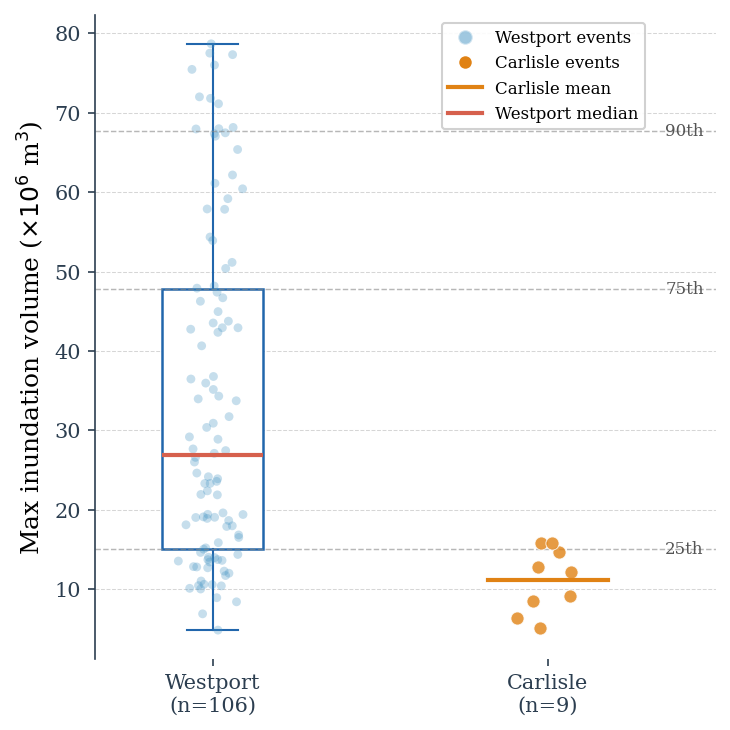

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import adjustText

GRAPH_OUTPUT_DIR = f"/home/91/23016891/projects/carlisle/out"

peaks_df          = pd.read_csv(os.path.join(GRAPH_OUTPUT_DIR, "westport",  "event_peaks.csv"))
peaks_df_carlisle = pd.read_csv(os.path.join(GRAPH_OUTPUT_DIR, "carlisle",  "event_peaks.csv"))

# ── Event classification ──────────────────────────────────────────────────────
p25      = peaks_df["peak_volume"].quantile(0.25)
p75      = peaks_df["peak_volume"].quantile(0.75)
p90      = peaks_df["peak_volume"].quantile(0.90)
p_med_ttp = peaks_df["peak_volume_timestep"].median()

def classify_volume(v):
    if v > p90:  return "extreme"
    if v > p75:  return "high"
    if v >= p25: return "medium"
    return "low"

peaks_df["volume_class"] = peaks_df["peak_volume"].apply(classify_volume)
peaks_df["ttp_class"]    = np.where(
    peaks_df["peak_volume_timestep"] <= p_med_ttp, "fast", "slow"
)
peaks_df["combination"]  = peaks_df["volume_class"] + "-" + peaks_df["ttp_class"]

# ── Test event selection ──────────────────────────────────────────────────────
selected_ids = []

# 2 extreme events: highest two peak volumes above 90th percentile. Make sure to add the event IDs with the highest flow and highest sea level events if they are not already included in the extreme events.
extreme_events = (peaks_df[peaks_df["volume_class"] == "extreme"]
                  .nlargest(1, "peak_volume"))
selected_ids.extend(extreme_events["event_id"].tolist())

# Add the event IDs with the highest flow and highest sea level events if they are not already included in the extreme events
if peaks_df.loc[peaks_df["peak_flow"].idxmax(), "event_id"] not in selected_ids:
    selected_ids.append(peaks_df.loc[peaks_df["peak_flow"].idxmax(), "event_id"])

if peaks_df.loc[peaks_df["peak_sea_level"].idxmax(), "event_id"] not in selected_ids:
    selected_ids.append(peaks_df.loc[peaks_df["peak_sea_level"].idxmax(), "event_id"])

# 1 events per combination for medium and high bands
for combo in ["medium-fast", "medium-slow", "high-fast", "high-slow"]:
    pool = peaks_df[
        (peaks_df["combination"] == combo) &
        (~peaks_df["event_id"].isin(selected_ids))
    ]
    if len(pool) >= 1:
        #find the 50th percentile of peak volume and time to peak for the pool
        median_v   = pool["peak_volume"].median()
        median_ttp = pool["peak_volume_timestep"].median()

        # Ones closest to median volume
        closest_v   = pool.iloc[(pool["peak_volume"] - median_v).abs().argsort()]
        #now find the ones closest to median time to peak among the ones closest to median volume
        closest_v   = closest_v.iloc[(closest_v["peak_volume_timestep"] - median_ttp).abs().argsort()].iloc[0]

        chosen = pd.DataFrame([closest_v])
    else:
        chosen = pool
    selected_ids.extend(chosen["event_id"].tolist())

peaks_df["selected"] = peaks_df["event_id"].isin(selected_ids)

# ── Save selected events to CSV ───────────────────────────────────────────────
peaks_df[peaks_df["selected"]][[
    "event_id", "peak_volume", "peak_volume_timestep",
    "volume_class", "ttp_class", "combination"
]].rename(columns={
    "peak_volume":          "max_volume_m3",
    "peak_volume_timestep": "time_to_max_volume_hours",
}).to_csv(os.path.join(GRAPH_OUTPUT_DIR, "selected_test_events.csv"), index=False)

# ── Publication style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.labelsize":   12,
    "axes.titlesize":   12,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "legend.fontsize":  10,
    "figure.dpi":       150,
    "axes.linewidth":   0.8,
    "grid.linewidth":   0.5,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
})

DOT_COLOR      = "#4393c3"   # uniform colour for all dots
SEL_EDGE_COLOR = "#000078"   # red outline for selected events
SEL_COLOR      = "#000000"


# ── Figure 1: Westport boxplot + Carlisle dot strip — same axis ──────────────
fig, ax = plt.subplots(figsize=(5, 5))

volumes = peaks_df["peak_volume"].values / 1e6
vols_c  = peaks_df_carlisle["peak_volume"].values / 1e6

# ── Westport: full boxplot at x=1 ────────────────────────────────────────────
ax.boxplot(
    volumes, positions=[1], vert=True, patch_artist=True, widths=0.3,
    boxprops=dict(facecolor="white", edgecolor="#2166ac", linewidth=1.2),
    medianprops=dict(color="#d6604d", linewidth=2),
    whiskerprops=dict(color="#2166ac", linewidth=1.0),
    capprops=dict(color="#2166ac", linewidth=1.0),
    flierprops=dict(marker="o", markerfacecolor="#bbbbbb",
                    markeredgewidth=0, markersize=4, alpha=0.5),
)
np.random.seed(0)
ax.scatter(np.random.normal(1, 0.04, size=len(volumes)), volumes,
           color=DOT_COLOR, alpha=0.3, s=18, edgecolors="none", zorder=2)

# ── Carlisle: dots only + mean line at x=2 ───────────────────────────────────
CARLISLE_COLOR = "#e08214"
np.random.seed(1)
ax.scatter(np.random.normal(2, 0.04, size=len(vols_c)), vols_c,
           color=CARLISLE_COLOR, alpha=0.8, s=40,
           edgecolors="white", linewidth=0.5, zorder=3)

# Mean line for Carlisle
mean_c = np.mean(vols_c)
ax.plot([1.82, 2.18], [mean_c, mean_c],
        color=CARLISLE_COLOR, linewidth=2, linestyle="-", zorder=4)

# ── Percentile threshold lines (Westport only) ───────────────────────────────
for val, label in [(p25/1e6, "25th"), (p75/1e6, "75th"), (p90/1e6, "90th")]:
    ax.axhline(val, color="#888888", linewidth=0.7, linestyle="--", alpha=0.6)
    ax.text(2.35, val, label, fontsize=8, va="center", color="#555555")
    
    # ── Annotate highest peak flow and peak sea level events ─────────────────────
max_flow_vol  = peaks_df.loc[peaks_df["peak_flow"].idxmax(),  "peak_volume"] / 1e6
max_sl_vol    = peaks_df.loc[peaks_df["peak_sea_level"].idxmax(), "peak_volume"] / 1e6
 
# ax.annotate("Max flow", xy=(1, max_flow_vol),
#             xytext=(1.45, max_flow_vol),
#             fontsize=7.5, color="#1a6b1a", va="center",
#             arrowprops=dict(arrowstyle="-", color="#1a6b1a", lw=0.7))
 
# ax.annotate("Max sea level", xy=(1, max_sl_vol),
#             xytext=(1.45, max_sl_vol + (0.8 if abs(max_sl_vol - max_flow_vol) < 1 else 0)),
#             fontsize=7.5, color="#7b3294", va="center",
#             arrowprops=dict(arrowstyle="-", color="#7b3294", lw=0.7))

# ── Axes styling ─────────────────────────────────────────────────────────────
ax.set_xticks([1, 2])
ax.set_xticklabels(["Westport\n(n=106)", "Carlisle\n(n=9)"], fontsize=10)
ax.set_xlim(0.65, 2.5)
ax.set_ylabel("Max inundation volume ($\\times 10^6$ m$^3$)", fontsize=12)
# ax.set_title("(a) Peak inundation volume", loc="left", fontsize=11, pad=6)
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#cccccc", alpha=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#2c3e50")
ax.tick_params(colors="#2c3e50", labelsize=10)

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [
    plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=DOT_COLOR,
               markersize=7, alpha=0.5, label="Westport events"),
    plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=CARLISLE_COLOR,
               markersize=7, label="Carlisle events"),
    plt.Line2D([0],[0], color=CARLISLE_COLOR, linewidth=2, label="Carlisle mean"),
    plt.Line2D([0],[0], color="#d6604d",      linewidth=2, label="Westport median"),
]
ax.legend(handles=handles, fontsize=8, frameon=True,
          framealpha=0.9, edgecolor="#cccccc", loc="upper right", bbox_to_anchor=(0.9, 1.0))

plt.tight_layout()
plt.savefig(os.path.join(GRAPH_OUTPUT_DIR, "fig_peak_volume_boxplot.pdf"))
plt.savefig(os.path.join(GRAPH_OUTPUT_DIR, "fig_peak_volume_boxplot.png"))
plt.show()




In [25]:
peaks_df

,event_id,event_duration_hours,number_of_timesteps,event_name,peak_flow,peak_timestep,peak_sea_level,peak_sea_level_timestep,peak_volume,peak_volume_timestep,volume_class,ttp_class,combination,selected
0,1,49.0,50,Base0_Buller20yrARI_v2,7451.250000,38.0,1.873421,3.0,33729760.0,40.0,medium,slow,medium-slow,True
1,2,49.0,50,Base1_Buller50yrARI_v2,8514.321667,38.0,1.873421,3.0,42343232.0,40.0,medium,slow,medium-slow,False
2,3,49.0,50,Base2_Buller100yrARI,9304.310000,38.0,1.873421,3.0,50390348.0,40.0,high,slow,high-slow,False
3,4,53.0,54,Base3_Buller50yrARI_RCP4pt5,9504.999103,41.0,2.631618,6.0,60410496.0,43.0,high,slow,high-slow,False
4,5,56.0,57,Base4_Buller50yrARI_RCP6pt0,9829.359435,43.0,2.827800,8.0,65355112.0,45.0,high,slow,high-slow,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,102,39.0,79,S93,6300.000000,16.0,2.150000,20.0,26021778.0,20.5,medium,slow,medium-slow,False
102,103,34.0,69,S94,4200.000000,14.0,3.000000,17.0,26609392.0,17.5,medium,fast,medium-fast,False
103,104,27.0,55,S95,1800.000000,14.0,2.010000,9.0,11736127.0,9.5,low,fast,low-fast,False
104,105,34.0,69,S96,5400.000000,14.0,2.550000,17.5,24634980.0,18.0,medium,fast,medium-fast,True


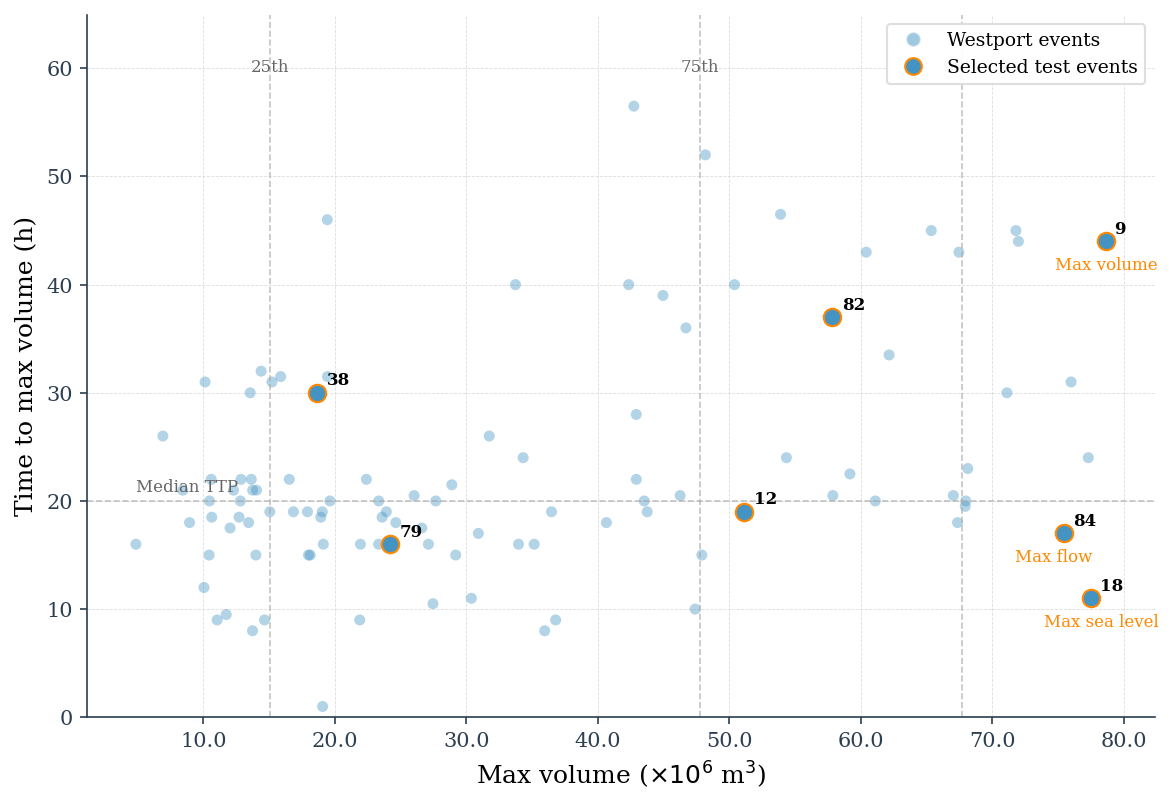


Percentile thresholds:
  25th (low/medium boundary):   15.091 × 10⁶ m³
  75th (medium/high boundary):  47.777 × 10⁶ m³
  90th (high/extreme boundary): 67.697 × 10⁶ m³
  Median time to peak:          20.0 h

Selected test events (7 total):
 event_id  max_volume_m3  time_to_peak_h  combination  event_duration_hours
        9     78656176.0            44.0 extreme-slow                  56.0
       12     51149448.0            19.0    high-fast                  30.0
       18     77481944.0            11.0 extreme-fast                  13.0
       38     18661618.0            30.0  medium-slow                  50.0
       79     24170182.0            16.0  medium-fast                  24.0
       82     57829160.0            37.0    high-slow                  67.0
       84     75438064.0            17.0 extreme-fast                  44.0
Selected validation event IDs: [26, 73]
 event_id  max_volume_m3  time_to_peak_h combination  event_duration_hours
       26     27670442.0            2

In [6]:
# ── Figure 2: Scatter — volume vs time to peak, selected events labelled ──────
from adjustText import adjust_text

DOT_COLOR      = "#4393c3"   # uniform colour for all dots
SEL_EDGE_COLOR = "#FF8800"  # outline for selected events
SEL_COLOR      = "#000000"
 
fig, ax = plt.subplots(figsize=(8, 5.5))
 
# Westport — all unselected events
not_selected = peaks_df[~peaks_df["selected"]]
ax.scatter(
    not_selected["peak_volume"] / 1e6,
    not_selected["peak_volume_timestep"],
    color=DOT_COLOR, s=28, alpha=0.4, edgecolors="none", zorder=2,
)
 
# Westport — selected events
selected = peaks_df[peaks_df["selected"]]
ax.scatter(
    selected["peak_volume"] / 1e6,
    selected["peak_volume_timestep"],
    color=DOT_COLOR, s=70, alpha=1.0,
    edgecolors=SEL_EDGE_COLOR, linewidth=1.0, zorder=5,
)
 
 
 
# Annotations with adjustText to resolve overlaps
texts = []
for _, row in selected.iterrows():
    t = ax.text(
        row["peak_volume"] / 1e6 + 0.5,
        row["peak_volume_timestep"] + 0.5,
        str(int(row["event_id"])),
        fontsize=8, color="#000000", fontweight="bold",
    )
    texts.append(t)
 
adjust_text(
    texts, ax=ax,
    arrowprops=dict(arrowstyle="-", color="#ffffff", lw=0.9),
    expand_points=(1.5, 1.5),
    force_points=(0.3, 0.3),
)
 
# Threshold lines
y_max = peaks_df["peak_volume_timestep"].max()
for val, label in [(p25/1e6, "25th"), (p75/1e6, "75th"), (p90/1e6, "90th")]:
    ax.axvline(val, color="#aaaaaa", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.text(val, y_max * 1.05, label, fontsize=8,
            ha="center", va="bottom", color="#666666")
 
ax.axhline(p_med_ttp, color="#aaaaaa", linewidth=0.8, linestyle="--", alpha=0.7)
ax.text(peaks_df["peak_volume"].min() / 1e6, p_med_ttp + 0.5,
        "Median TTP", fontsize=8, ha="left", va="bottom", color="#666666")

# ── Mark event with highest peak flow and peak sea level ─────────────────────
max_flow_row = peaks_df.loc[peaks_df["peak_flow"].idxmax()]
max_sl_row   = peaks_df.loc[peaks_df["peak_sea_level"].idxmax()]

ax.annotate(
    "Max flow",
    xy=(max_flow_row["peak_volume"] / 1e6, max_flow_row["peak_volume_timestep"]),
    xytext=(max_flow_row["peak_volume"] / 1e6 - 0.8, max_flow_row["peak_volume_timestep"] - 3),
    fontsize=8, color="#FF8800",
    va="bottom", ha="center",
)

ax.annotate(
    "Max sea level",
    xy=(max_sl_row["peak_volume"] / 1e6, max_sl_row["peak_volume_timestep"]),
    xytext=(max_sl_row["peak_volume"] / 1e6 + 0.8, max_sl_row["peak_volume_timestep"] - 3),
    fontsize=8, color="#FF8800",
    va="bottom", ha="center",
)

ax.annotate(
    "Max volume",
    xy=(selected[selected["peak_volume"] == selected["peak_volume"].max()]["peak_volume"].values[0] / 1e6,
        selected[selected["peak_volume"] == selected["peak_volume"].max()]["peak_volume_timestep"].values[0]),
    xytext=(selected[selected["peak_volume"] == selected["peak_volume"].max()]["peak_volume"].values[0] / 1e6, selected[selected["peak_volume"] == selected["peak_volume"].max()]["peak_volume_timestep"].values[0] - 3),
    fontsize=8, color="#FF8800",
    va="bottom", ha="center",
)

 
# Legend
handles = [
    plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=DOT_COLOR,
               alpha=0.5, markersize=7, label="Westport events"),
    plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=DOT_COLOR,
               markeredgecolor=SEL_EDGE_COLOR, markeredgewidth=1.0,
               markersize=8, label="Selected test events"),
]
ax.legend(handles=handles, fontsize=9, frameon=True,
          framealpha=0.95, edgecolor="#dddddd", loc="upper right")
 
ax.set_xlabel("Max volume ($\\times 10^6$ m$^3$)", fontsize=12)
ax.set_ylabel("Time to max volume (h)", fontsize=12)
# ax.set_title("(b) Test event selection", loc="left", fontsize=11, pad=6)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}"))
ax.set_ylim(bottom=0, top=y_max * 1.15)
ax.yaxis.grid(True, linestyle="--", linewidth=0.4, color="#dddddd")
ax.xaxis.grid(True, linestyle="--", linewidth=0.4, color="#dddddd")
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#2c3e50")
ax.spines["bottom"].set_color("#2c3e50")
ax.tick_params(colors="#2c3e50", labelsize=10)
 
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_OUTPUT_DIR, "fig_test_event_selection.pdf"))
plt.savefig(os.path.join(GRAPH_OUTPUT_DIR, "fig_test_event_selection.png"))
plt.show()
 
# ── Print summary ─────────────────────────────────────────────────────────────
print(f"\nPercentile thresholds:")
print(f"  25th (low/medium boundary):   {p25/1e6:.3f} × 10⁶ m³")
print(f"  75th (medium/high boundary):  {p75/1e6:.3f} × 10⁶ m³")
print(f"  90th (high/extreme boundary): {p90/1e6:.3f} × 10⁶ m³")
print(f"  Median time to peak:          {p_med_ttp:.1f} h")
 
print(f"\nSelected test events ({len(selected_ids)} total):")
print(peaks_df[peaks_df["selected"]][[
    "event_id", "peak_volume", "peak_volume_timestep", "combination", "event_duration_hours"
]].rename(columns={
    "peak_volume":          "max_volume_m3",
    "peak_volume_timestep": "time_to_peak_h",
}).to_string(index=False))

#selected validation evets
# Validation event selection — 1 medium, 1 high, closest to centre of each band
validation_ids = []

for band in ["medium", "high"]:
    pool = peaks_df[
        (peaks_df["volume_class"] == band) &
        (~peaks_df["event_id"].isin(selected_ids))
    ].copy()

    if len(pool) >= 1:
        pool["v_norm"]   = (pool["peak_volume"] - pool["peak_volume"].min()) / \
                           (pool["peak_volume"].max() - pool["peak_volume"].min() + 1e-9)
        pool["ttp_norm"] = (pool["peak_volume_timestep"] - pool["peak_volume_timestep"].min()) / \
                           (pool["peak_volume_timestep"].max() - pool["peak_volume_timestep"].min() + 1e-9)

        pool["dist_to_centre"] = np.sqrt(
            (pool["v_norm"]   - pool["v_norm"].median())  **2 +
            (pool["ttp_norm"] - pool["ttp_norm"].median())**2
        )
        validation_ids.extend(pool.nsmallest(1, "dist_to_centre")["event_id"].tolist())

print(f"Selected validation event IDs: {validation_ids}")
print(peaks_df[peaks_df["event_id"].isin(validation_ids)][[
    "event_id", "peak_volume", "peak_volume_timestep", "combination", "event_duration_hours"
]].rename(columns={
    "peak_volume":          "max_volume_m3",
    "peak_volume_timestep": "time_to_peak_h",
}).to_string(index=False))
peaks_df["validation"] = peaks_df["event_id"].isin(validation_ids)

In [4]:
peaks_df["validation"]

0      False
1      False
2      False
3      False
4      False
       ...  
101    False
102    False
103    False
104    False
105    False
Name: validation, Length: 106, dtype: bool